# Exploratory Prediction-Error Audit



## Analysis protocol

- **Unit of analysis:** one multi-label test item.
- **Canonical label order:** anger, disgust, fear, joy, sadness, surprise.
- **Automatic diagnostics:** macro-F1, subset accuracy, Hamming loss, sample-level Jaccard, false-positive and false-negative labels, and relative label-error counts.
- **Sampling:** 30 items per language, seed 42. Sampling balances cases where System A makes fewer label errors, System B makes fewer label errors, and both make the same number of label errors while at least one is incorrect. Within each group it promotes coverage of different gold emotions.
- **Structured audit fields:** one primary error-pattern category, optional secondary category, explicitness, cultural/idiomatic content, code-switching, annotation plausibility, notes, and report inclusion.
- **Reporting boundary:** descriptive and interpretive only. This analysis does not establish causal mechanisms.


In [ ]:
# 1. Environment and canonical paths
from google.colab import drive
drive.mount("/content/drive")

import hashlib
import json
import os
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from openpyxl import load_workbook
from openpyxl.styles import Alignment, Font, PatternFill
from openpyxl.workbook.defined_name import DefinedName
from openpyxl.worksheet.datavalidation import DataValidation
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    hamming_loss,
    jaccard_score,
)

SEED = 42
SAMPLE_PER_LANGUAGE = 30
REBUILD_CODING_WORKBOOK = False

PROJECT_DIR = Path("/content/drive/MyDrive/EmotionDetection")
CHECKPOINT_DIR = PROJECT_DIR / "CAST_checkpoints"
CACHE_DIR = CHECKPOINT_DIR / "data_cache"
PHASE1_PRED_DIR = CHECKPOINT_DIR / "Phase1" / "predictions"
PHASE3_PRED_DIR = CHECKPOINT_DIR / "Phase3" / "predictions"

OUTPUT_DIR = CHECKPOINT_DIR / "QualitativeErrorAnalysis"
RESULTS_DIR = OUTPUT_DIR / "results"
FIGURES_DIR = OUTPUT_DIR / "figures"
METADATA_DIR = OUTPUT_DIR / "metadata"

for directory in (OUTPUT_DIR, RESULTS_DIR, FIGURES_DIR, METADATA_DIR):
    directory.mkdir(parents=True, exist_ok=True)

CODING_WORKBOOK = RESULTS_DIR / "prediction_error_audit_workbook.xlsx"
CODED_SUMMARY_CSV = RESULTS_DIR / "prediction_error_audit_summary.csv"
REPORT_TEXT_PATH = RESULTS_DIR / "report_ready_interpretation.md"

EMOTIONS = ["anger", "disgust", "fear", "joy", "sadness", "surprise"]

print(f"Project: {PROJECT_DIR}")
print(f"Output:  {OUTPUT_DIR}")
print("No model training or inference will be performed.")


Mounted at /content/drive
Project: /content/drive/MyDrive/EmotionDetection
Output:  /content/drive/MyDrive/EmotionDetection/CAST_checkpoints/QualitativeErrorAnalysis
No model training or inference will be performed.


In [ ]:
# 2. Pre-registered case manifest
CASES = {
    "sun": {
        "language": "Sundanese",
        "rationale": (
            "Explains the large Phase 1 gap and whether XLM-R's low macro-F1 "
            "reflects failure to recover parts of the emotion label repertoire."
        ),
        "system_a_name": "XLM-R Phase 1 Track A",
        "system_a_path": PHASE1_PRED_DIR / "phase1_xlmr_a_sun_mono.json",
        "system_b_name": "Gemma P0 (canonical Phase 2 execution)",
        "system_b_path": PHASE1_PRED_DIR / "phase2_sun_p0.json",
    },
    "kin": {
        "language": "Kinyarwanda",
        "rationale": (
            "Examines a controlled Phase 3 same-pool backbone comparison for "
            "the language with the largest observed SERENGETI advantage."
        ),
        "system_a_name": "XLM-R Phase 3 Track A C1",
        "system_a_path": PHASE3_PRED_DIR / "phase3xlmrW_kin_track_a_C1.json",
        "system_b_name": "SERENGETI Phase 3 Track A C1",
        "system_b_path": PHASE3_PRED_DIR / "phase3srng_kin_track_a_C1.json",
    },
    "yor": {
        "language": "Yoruba",
        "rationale": (
            "Examines the same C3 pool across backbones, directly supporting "
            "interpretation of the observed backbone-by-pool interaction."
        ),
        "system_a_name": "XLM-R Phase 3 Track A C3",
        "system_a_path": PHASE3_PRED_DIR / "phase3xlmrW_yor_track_a_C3.json",
        "system_b_name": "SERENGETI Phase 3 Track A C3",
        "system_b_path": PHASE3_PRED_DIR / "phase3srng_yor_track_a_C3.json",
    },
}

manifest_preview = pd.DataFrame(
    [
        {
            "code": code,
            "language": spec["language"],
            "system_a": spec["system_a_name"],
            "system_b": spec["system_b_name"],
            "rationale": spec["rationale"],
        }
        for code, spec in CASES.items()
    ]
)
display(manifest_preview)


,code,language,system_a,system_b,rationale
0,sun,Sundanese,XLM-R Phase 1 Track A,Gemma P0 (canonical Phase 2 execution),Explains the large Phase 1 gap and whether XLM...
1,kin,Kinyarwanda,XLM-R Phase 3 Track A C1,SERENGETI Phase 3 Track A C1,Examines a controlled Phase 3 same-pool backbo...
2,yor,Yoruba,XLM-R Phase 3 Track A C3,SERENGETI Phase 3 Track A C3,"Examines the same C3 pool across backbones, di..."


In [ ]:
# 3. Validated loading and utility functions

def sha256_file(path):
    digest = hashlib.sha256()
    with open(path, "rb") as handle:
        for block in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()


def load_prediction(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(path)

    with open(path, "r", encoding="utf-8") as handle:
        payload = json.load(handle)

    required = {"emotions", "y_true", "y_pred"}
    missing = required - set(payload)
    if missing:
        raise ValueError(f"{path}: missing keys {sorted(missing)}")

    stored_emotions = list(payload["emotions"])
    if len(stored_emotions) != len(set(stored_emotions)):
        raise ValueError(f"{path}: duplicate emotion names")
    if set(stored_emotions) != set(EMOTIONS):
        raise ValueError(
            f"{path}: expected emotion set {EMOTIONS}, found {stored_emotions}"
        )

    y_true = np.asarray(payload["y_true"], dtype=np.int8)
    y_pred = np.asarray(payload["y_pred"], dtype=np.int8)

    if y_true.ndim != 2 or y_true.shape != y_pred.shape:
        raise ValueError(
            f"{path}: incompatible arrays y_true={y_true.shape}, "
            f"y_pred={y_pred.shape}"
        )
    if y_true.shape[1] != len(stored_emotions):
        raise ValueError(f"{path}: stored emotion names do not match columns")
    if not set(np.unique(y_true)).issubset({0, 1}):
        raise ValueError(f"{path}: y_true is not binary")
    if not set(np.unique(y_pred)).issubset({0, 1}):
        raise ValueError(f"{path}: y_pred is not binary")

    order = [stored_emotions.index(emotion) for emotion in EMOTIONS]
    return y_true[:, order], y_pred[:, order], sha256_file(path)


def load_test_split(code):
    path = CACHE_DIR / f"{code}_test.parquet"
    if not path.exists():
        raise FileNotFoundError(path)

    frame = pd.read_parquet(path).reset_index(drop=True)
    required = {"text", *EMOTIONS}
    missing = required - set(frame.columns)
    if missing:
        raise ValueError(f"{path}: missing columns {sorted(missing)}")

    gold = (
        frame[EMOTIONS]
        .fillna(0)
        .astype(np.int8)
        .to_numpy()
    )
    if not set(np.unique(gold)).issubset({0, 1}):
        raise ValueError(f"{path}: gold label columns are not binary")

    return frame, gold, path, sha256_file(path)


def labels_from_row(row):
    labels = [emotion for emotion, value in zip(EMOTIONS, row) if value == 1]
    return "|".join(labels) if labels else "none"


def anonymise_text(value):
    text = str(value)
    text = re.sub(r"https?://\S+|www\.\S+", "[URL]", text)
    text = re.sub(r"(?<!\w)@\w+", "[USER]", text)
    text = re.sub(r"\b[\w.+-]+@[\w.-]+\.[A-Za-z]{2,}\b", "[EMAIL]", text)
    return text


def system_metrics(y_true, y_pred):
    return {
        "macro_f1": float(
            f1_score(y_true, y_pred, average="macro", zero_division=0)
        ),
        "subset_accuracy": float(accuracy_score(y_true, y_pred)),
        "hamming_loss": float(hamming_loss(y_true, y_pred)),
        "sample_jaccard": float(
            jaccard_score(
                y_true,
                y_pred,
                average="samples",
                zero_division=0,
            )
        ),
    }


def round_robin_emotions(frame, n, rng):
    if frame.empty or n <= 0:
        return frame.iloc[0:0].copy()

    shuffled = frame.assign(_random=rng.random(len(frame)))
    shuffled = shuffled.sort_values(["anchor_emotion", "_random"])
    groups = {
        key: group.drop(columns="_random").to_dict("records")
        for key, group in shuffled.groupby("anchor_emotion", sort=True)
    }

    chosen = []
    keys = list(groups)
    while len(chosen) < n and any(groups.values()):
        for key in keys:
            if groups[key] and len(chosen) < n:
                chosen.append(groups[key].pop(0))

    return pd.DataFrame(chosen, columns=frame.columns)


def deterministic_balanced_sample(frame, target_n, seed):
    candidates = frame.loc[
        (frame["system_a_error_count"] > 0)
        | (frame["system_b_error_count"] > 0)
    ].copy()

    if len(candidates) < target_n:
        raise ValueError(
            f"Only {len(candidates)} error candidates available; "
            f"{target_n} requested."
        )

    rng = np.random.default_rng(seed)
    groups = [
        "system_a_fewer_errors",
        "system_b_fewer_errors",
        "equal_label_errors",
    ]
    base_quota = target_n // len(groups)
    remainder = target_n % len(groups)

    selected_parts = []
    selected_ids = set()
    for index, group_name in enumerate(groups):
        quota = base_quota + (1 if index < remainder else 0)
        group_frame = candidates.loc[
            candidates["relative_error_status"] == group_name
        ]
        part = round_robin_emotions(
            group_frame,
            min(quota, len(group_frame)),
            rng,
        )
        selected_parts.append(part)
        selected_ids.update(part["item_id"].tolist())

    selected = pd.concat(selected_parts, ignore_index=True)
    shortfall = target_n - len(selected)

    if shortfall:
        remaining = candidates.loc[
            ~candidates["item_id"].isin(selected_ids)
        ]
        fill = round_robin_emotions(remaining, shortfall, rng)
        selected = pd.concat([selected, fill], ignore_index=True)

    if len(selected) != target_n:
        raise AssertionError(
            f"Sampling produced {len(selected)} rows, expected {target_n}"
        )
    if selected["item_id"].duplicated().any():
        raise AssertionError("Sampling produced duplicate items")

    return selected


In [ ]:
# 4. Join texts to archived predictions and calculate automatic diagnostics
all_item_tables = []
system_summary_rows = []
label_summary_rows = []
manifest_rows = []
loaded_cases = {}

for case_index, (code, spec) in enumerate(CASES.items()):
    test_frame, dataset_gold, test_path, test_hash = load_test_split(code)
    a_true, a_pred, a_hash = load_prediction(spec["system_a_path"])
    b_true, b_pred, b_hash = load_prediction(spec["system_b_path"])

    if dataset_gold.shape != a_true.shape or dataset_gold.shape != b_true.shape:
        raise ValueError(
            f"{code}: row/column mismatch among dataset and prediction files"
        )
    if not np.array_equal(dataset_gold, a_true):
        raise ValueError(
            f"{code}: System A gold array does not match cached test data"
        )
    if not np.array_equal(dataset_gold, b_true):
        raise ValueError(
            f"{code}: System B gold array does not match cached test data"
        )
    if not np.array_equal(a_true, b_true):
        raise ValueError(f"{code}: prediction files use different gold arrays")

    for role, name, prediction in [
        ("system_a", spec["system_a_name"], a_pred),
        ("system_b", spec["system_b_name"], b_pred),
    ]:
        metrics = system_metrics(dataset_gold, prediction)
        system_summary_rows.append(
            {
                "code": code,
                "language": spec["language"],
                "system_role": role,
                "system": name,
                "n_test": len(test_frame),
                **metrics,
            }
        )
        per_label = f1_score(
            dataset_gold,
            prediction,
            average=None,
            zero_division=0,
        )
        for emotion, value in zip(EMOTIONS, per_label):
            label_summary_rows.append(
                {
                    "code": code,
                    "language": spec["language"],
                    "system_role": role,
                    "system": name,
                    "emotion": emotion,
                    "f1": float(value),
                    "gold_positive_count": int(
                        dataset_gold[:, EMOTIONS.index(emotion)].sum()
                    ),
                    "predicted_positive_count": int(
                        prediction[:, EMOTIONS.index(emotion)].sum()
                    ),
                }
            )

    rows = []
    for item_index in range(len(test_frame)):
        gold = dataset_gold[item_index]
        pred_a = a_pred[item_index]
        pred_b = b_pred[item_index]
        a_fp = np.flatnonzero((pred_a == 1) & (gold == 0))
        a_fn = np.flatnonzero((pred_a == 0) & (gold == 1))
        b_fp = np.flatnonzero((pred_b == 1) & (gold == 0))
        b_fn = np.flatnonzero((pred_b == 0) & (gold == 1))
        a_error_count = int(len(a_fp) + len(a_fn))
        b_error_count = int(len(b_fp) + len(b_fn))

        if a_error_count < b_error_count:
            relative_status = "system_a_fewer_errors"
        elif b_error_count < a_error_count:
            relative_status = "system_b_fewer_errors"
        else:
            relative_status = "equal_label_errors"

        gold_labels = [EMOTIONS[i] for i in np.flatnonzero(gold)]
        anchor_emotion = gold_labels[0] if gold_labels else "none"

        rows.append(
            {
                "item_id": f"{code}_{item_index:05d}",
                "code": code,
                "language": spec["language"],
                "row_index": item_index,
                "text_raw": str(test_frame.loc[item_index, "text"]),
                "text_anonymised": anonymise_text(
                    test_frame.loc[item_index, "text"]
                ),
                "gold_labels": labels_from_row(gold),
                "anchor_emotion": anchor_emotion,
                "system_a": spec["system_a_name"],
                "system_a_prediction": labels_from_row(pred_a),
                "system_a_false_positives": "|".join(
                    EMOTIONS[i] for i in a_fp
                ),
                "system_a_false_negatives": "|".join(
                    EMOTIONS[i] for i in a_fn
                ),
                "system_a_error_count": a_error_count,
                "system_b": spec["system_b_name"],
                "system_b_prediction": labels_from_row(pred_b),
                "system_b_false_positives": "|".join(
                    EMOTIONS[i] for i in b_fp
                ),
                "system_b_false_negatives": "|".join(
                    EMOTIONS[i] for i in b_fn
                ),
                "system_b_error_count": b_error_count,
                "prediction_disagreement_count": int(
                    np.abs(pred_a - pred_b).sum()
                ),
                "relative_error_status": relative_status,
            }
        )

    case_table = pd.DataFrame(rows)
    loaded_cases[code] = case_table
    all_item_tables.append(case_table)

    result_path = RESULTS_DIR / f"{code}_all_item_diagnostics.csv"
    case_table.to_csv(result_path, index=False)

    manifest_rows.extend(
        [
            {
                "code": code,
                "language": spec["language"],
                "artifact_role": "test_data",
                "path": str(test_path),
                "sha256": test_hash,
                "rows": len(test_frame),
                "rationale": spec["rationale"],
            },
            {
                "code": code,
                "language": spec["language"],
                "artifact_role": "system_a_predictions",
                "path": str(spec["system_a_path"]),
                "sha256": a_hash,
                "rows": len(a_true),
                "rationale": spec["rationale"],
            },
            {
                "code": code,
                "language": spec["language"],
                "artifact_role": "system_b_predictions",
                "path": str(spec["system_b_path"]),
                "sha256": b_hash,
                "rows": len(b_true),
                "rationale": spec["rationale"],
            },
        ]
    )

all_items = pd.concat(all_item_tables, ignore_index=True)
system_summary = pd.DataFrame(system_summary_rows)
label_summary = pd.DataFrame(label_summary_rows)
manifest = pd.DataFrame(manifest_rows)

system_summary.to_csv(RESULTS_DIR / "system_summary.csv", index=False)
label_summary.to_csv(RESULTS_DIR / "label_summary.csv", index=False)
manifest.to_csv(METADATA_DIR / "analysis_manifest.csv", index=False)

print("All prediction files matched the cached BRIGHTER gold arrays exactly.")
display(system_summary.round(4))


All prediction files matched the cached BRIGHTER gold arrays exactly.


,code,language,system_role,system,n_test,macro_f1,subset_accuracy,hamming_loss,sample_jaccard
0,sun,Sundanese,system_a,XLM-R Phase 1 Track A,1852,0.2026,0.0475,0.2500,0.4221
1,sun,Sundanese,system_b,Gemma P0 (canonical Phase 2 execution),1852,0.5606,0.5032,0.1177,0.6232
2,kin,Kinyarwanda,system_a,XLM-R Phase 3 Track A C1,2462,0.3743,0.3582,0.1573,0.3702
3,kin,Kinyarwanda,system_b,SERENGETI Phase 3 Track A C1,2462,0.5709,0.5370,0.1014,0.4745
4,yor,Yoruba,system_a,XLM-R Phase 3 Track A C3,3000,0.2674,0.4093,0.1380,0.2270
5,yor,Yoruba,system_b,SERENGETI Phase 3 Track A C3,3000,0.3394,0.4727,0.1171,0.2681


In [ ]:
# 5. Create the deterministic prediction-error audit sample
sample_parts = []
for case_index, code in enumerate(CASES):
    selected = deterministic_balanced_sample(
        loaded_cases[code], SAMPLE_PER_LANGUAGE, SEED + case_index,
    )
    sample_parts.append(selected)

coding_sample = pd.concat(sample_parts, ignore_index=True)

coding_sample.insert(0, "review_order", np.arange(1, len(coding_sample) + 1))

annotation_columns = {
    "primary_error_category": "",
    "secondary_error_category": "",
    "emotion_expression_explicitness": "",
    "cultural_or_idiomatic_expression": "",
    "code_switching": "",
    "gold_annotation_plausible": "",
    "reviewer_notes": "",
    "include_in_report": "",
    "report_quote_anonymised": "",
}
for column, default in annotation_columns.items():
    coding_sample[column] = default

codebook = pd.DataFrame(
    [
        {
            "code": "implicit_or_context_dependent",
            "definition": (
                "The relevant emotion is conveyed indirectly through situation, "
                "event, or discourse context rather than an explicit emotion term."
            ),
            "apply_when": "Understanding the emotion requires contextual inference.",
            "avoid_when": "An explicit emotion word is the main cue.",
        },
        {
            "code": "idiomatic_or_culturally_specific",
            "definition": (
                "An idiom, metaphor, proverb, pragmatic convention, or culturally "
                "situated expression is central to the interpretation."
            ),
            "apply_when": "Literal reading misses the affective meaning.",
            "avoid_when": "The wording is ordinary and literal.",
        },
        {
            "code": "sarcasm_or_irony",
            "definition": (
                "The literal surface meaning conflicts with the intended affect."
            ),
            "apply_when": "Sarcasm, irony, mock praise, or rhetorical reversal is evident.",
            "avoid_when": "The statement is literal.",
        },
        {
            "code": "negation_or_scope",
            "definition": (
                "Negation, modality, attribution, or syntactic scope changes which "
                "emotion is actually asserted."
            ),
            "apply_when": "The model appears to ignore or misattach a scope cue.",
            "avoid_when": "No scope-sensitive construction is present.",
        },
        {
            "code": "code_switching_or_mixed_language",
            "definition": (
                "Multiple languages, scripts, or substantial borrowed material "
                "affect interpretation."
            ),
            "apply_when": "Mixed-language content is material to the error.",
            "avoid_when": "Only a common loanword or name occurs.",
        },
        {
            "code": "multi_label_overlap",
            "definition": (
                "Two or more emotion labels are simultaneously plausible or closely "
                "overlap in the item."
            ),
            "apply_when": "The error is better understood as label overlap than a clear miss.",
            "avoid_when": "One label is clearly supported and the other is not.",
        },
        {
            "code": "rare_label_or_category_collapse",
            "definition": (
                "The system systematically avoids a label or collapses several "
                "emotions into a small predicted repertoire."
            ),
            "apply_when": "The item exemplifies the per-label pattern shown in diagnostics.",
            "avoid_when": "Only an isolated mistake is visible.",
        },
        {
            "code": "annotation_ambiguity",
            "definition": (
                "The archived gold annotation is contestable, incomplete, or one of "
                "several defensible readings."
            ),
            "apply_when": "A careful reader could reasonably dispute the gold set.",
            "avoid_when": "The gold labels are clearly supported.",
        },
        {
            "code": "named_entity_or_topic_shortcut",
            "definition": (
                "A person, event, entity, or topic appears to trigger a stereotyped "
                "prediction rather than text-level affect."
            ),
            "apply_when": "The error follows topical association rather than expression.",
            "avoid_when": "The entity is irrelevant to the prediction.",
        },
        {
            "code": "orthographic_or_tokenisation_issue",
            "definition": (
                "Spelling variation, script, punctuation, segmentation, or malformed "
                "text plausibly impedes processing."
            ),
            "apply_when": "The form of the text is materially unusual or corrupted.",
            "avoid_when": "The text is normally formed.",
        },
        {
            "code": "other",
            "definition": "A clearly described error mechanism outside the codebook.",
            "apply_when": "Reviewer notes specify the alternative mechanism.",
            "avoid_when": "An existing code fits.",
        },
        {
            "code": "no_clear_error_mechanism",
            "definition": (
                "The item is misclassified, but no defensible qualitative mechanism "
                "can be assigned from the text alone."
            ),
            "apply_when": "Evidence is insufficient for a stronger explanation.",
            "avoid_when": "A codebook category is supported.",
        },
    ]
)

sampling_summary = (
    coding_sample.groupby(["language", "relative_error_status"])
    .size()
    .rename("n")
    .reset_index()
)

if CODING_WORKBOOK.exists() and not REBUILD_CODING_WORKBOOK:
    print(
        f"Existing coding workbook preserved: {CODING_WORKBOOK}\n"
        "Set REBUILD_CODING_WORKBOOK = True only if you intentionally "
        "want to replace manual annotations."
    )
else:
    with pd.ExcelWriter(CODING_WORKBOOK, engine="openpyxl") as writer:
        coding_sample.to_excel(writer, sheet_name="coding_sample", index=False)
        system_summary.to_excel(writer, sheet_name="system_summary", index=False)
        label_summary.to_excel(writer, sheet_name="label_summary", index=False)
        sampling_summary.to_excel(
            writer,
            sheet_name="sampling_summary",
            index=False,
        )
        codebook.to_excel(writer, sheet_name="codebook", index=False)
        manifest.to_excel(writer, sheet_name="manifest", index=False)

    workbook = load_workbook(CODING_WORKBOOK)
    sheet = workbook["coding_sample"]
    sheet.freeze_panes = "A2"
    sheet.auto_filter.ref = sheet.dimensions

    header_fill = PatternFill("solid", fgColor="1F4E78")
    for cell in sheet[1]:
        cell.font = Font(color="FFFFFF", bold=True)
        cell.fill = header_fill
        cell.alignment = Alignment(wrap_text=True, vertical="top")

    width_by_header = {
        "review_order": 12,
        "item_id": 14,
        "language": 16,
        "text_raw": 65,
        "text_anonymised": 65,
        "gold_labels": 24,
        "system_a_prediction": 24,
        "system_b_prediction": 24,
        "reviewer_notes": 55,
        "report_quote_anonymised": 65,
    }
    for column_cells in sheet.columns:
        header = column_cells[0].value
        width = width_by_header.get(header, 22)
        sheet.column_dimensions[column_cells[0].column_letter].width = width
        for cell in column_cells[1:]:
            cell.alignment = Alignment(wrap_text=True, vertical="top")

    category_range = DefinedName(
        "ErrorCategories",
        attr_text=f"'codebook'!$A$2:$A${len(codebook) + 1}",
    )
    if hasattr(workbook.defined_names, "add"):
        workbook.defined_names.add(category_range)
    else:
        workbook.defined_names.append(category_range)

    category_validation = DataValidation(
        type="list",
        formula1="ErrorCategories",
        allow_blank=True,
    )
    ternary_validation = DataValidation(
        type="list",
        formula1='"yes,no,uncertain"',
        allow_blank=True,
    )
    explicitness_validation = DataValidation(
        type="list",
        formula1='"explicit,implicit,mixed,uncertain"',
        allow_blank=True,
    )
    include_validation = DataValidation(
        type="list",
        formula1='"yes,no"',
        allow_blank=True,
    )

    header_to_column = {
        cell.value: cell.column_letter
        for cell in sheet[1]
    }
    max_row = sheet.max_row

    for validation, headers in [
        (
            category_validation,
            ["primary_error_category", "secondary_error_category"],
        ),
        (
            ternary_validation,
            [
                "cultural_or_idiomatic_expression",
                "code_switching",
                "gold_annotation_plausible",
            ],
        ),
        (
            explicitness_validation,
            ["emotion_expression_explicitness"],
        ),
        (
            include_validation,
            ["include_in_report"],
        ),
    ]:
        sheet.add_data_validation(validation)
        for header in headers:
            column = header_to_column[header]
            validation.add(f"{column}2:{column}{max_row}")

    workbook.save(CODING_WORKBOOK)
    print(f"Created coding workbook: {CODING_WORKBOOK}")

coding_sample.drop(columns="text_raw").to_csv(
    RESULTS_DIR / "qualitative_coding_sample_anonymised.csv",
    index=False,
)
sampling_summary.to_csv(
    RESULTS_DIR / "sampling_summary.csv",
    index=False,
)

print(f"Selected {len(coding_sample)} items.")
display(sampling_summary)


Existing coding workbook preserved: /content/drive/MyDrive/EmotionDetection/CAST_checkpoints/QualitativeErrorAnalysis/results/qualitative_error_coding.xlsx
Set REBUILD_CODING_WORKBOOK = True only if you intentionally want to replace manual annotations.
Selected 90 items.


,language,relative_error_status,n
0,Kinyarwanda,equal_label_errors,10
1,Kinyarwanda,system_a_fewer_errors,10
2,Kinyarwanda,system_b_fewer_errors,10
3,Sundanese,equal_label_errors,10
4,Sundanese,system_a_fewer_errors,10
5,Sundanese,system_b_fewer_errors,10
6,Yoruba,equal_label_errors,10
7,Yoruba,system_a_fewer_errors,10
8,Yoruba,system_b_fewer_errors,10


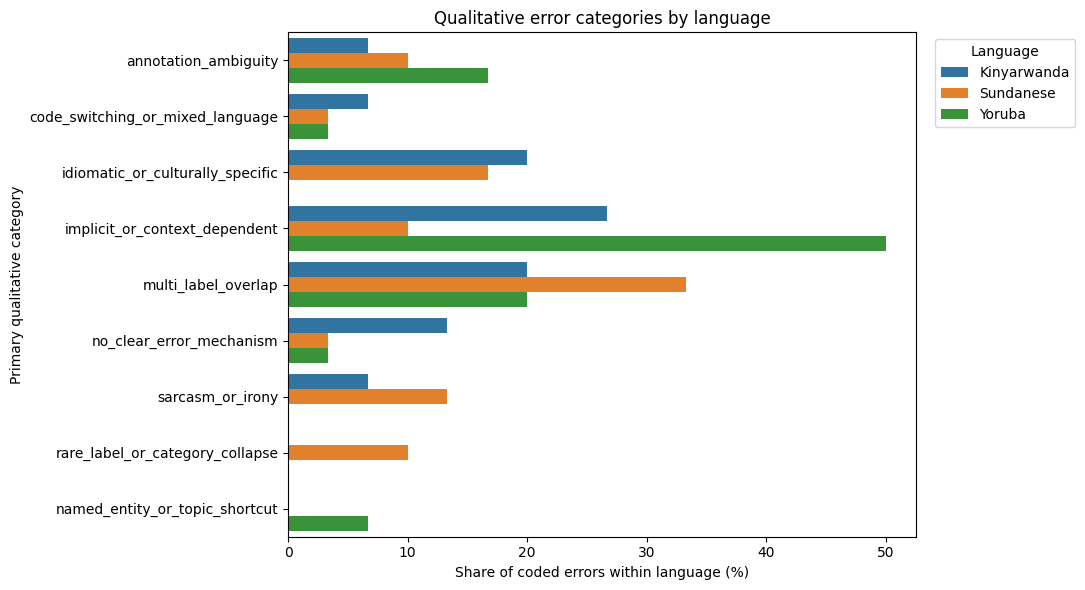

Coded rows: 90 / 90
Summary: /content/drive/MyDrive/EmotionDetection/CAST_checkpoints/QualitativeErrorAnalysis/results/qualitative_error_coded_summary.csv
Figure:  /content/drive/MyDrive/EmotionDetection/CAST_checkpoints/QualitativeErrorAnalysis/figures/qualitative_error_category_summary.png
Text:    /content/drive/MyDrive/EmotionDetection/CAST_checkpoints/QualitativeErrorAnalysis/results/report_ready_interpretation.md


,language,primary_error_category,count,percentage_within_language
0,Kinyarwanda,annotation_ambiguity,2,6.7
1,Kinyarwanda,code_switching_or_mixed_language,2,6.7
2,Kinyarwanda,idiomatic_or_culturally_specific,6,20.0
3,Kinyarwanda,implicit_or_context_dependent,8,26.7
4,Kinyarwanda,multi_label_overlap,6,20.0
5,Kinyarwanda,no_clear_error_mechanism,4,13.3
6,Kinyarwanda,sarcasm_or_irony,2,6.7
7,Sundanese,annotation_ambiguity,3,10.0
8,Sundanese,code_switching_or_mixed_language,1,3.3
9,Sundanese,idiomatic_or_culturally_specific,5,16.7


In [ ]:
# 6. Summarise completed prediction-error audit without overwriting it
if not CODING_WORKBOOK.exists():
    raise FileNotFoundError(CODING_WORKBOOK)

coded = pd.read_excel(CODING_WORKBOOK, sheet_name="coding_sample")
required_annotation_columns = set(annotation_columns)
missing = required_annotation_columns - set(coded.columns)
if missing:
    raise ValueError(f"Coding workbook is missing columns: {sorted(missing)}")

coded["primary_error_category"] = (
    coded["primary_error_category"]
    .fillna("")
    .astype(str)
    .str.strip()
)
completed = coded.loc[coded["primary_error_category"] != ""].copy()

if completed.empty:
    REPORT_TEXT_PATH.write_text(
        "# Qualitative error analysis\n\n"
        "The deterministic audit sample has been generated, but the "
        "prediction-error audit has not yet been completed. No label-level findings are "
        "reported until the sampled error cases have been reviewed.\n",
        encoding="utf-8",
    )
    print("Prediction-error audit has not yet been completed.")
    print(f"Open audit workbook: {CODING_WORKBOOK}")
    print(f"Placeholder interpretation written: {REPORT_TEXT_PATH}")
else:
    invalid_codes = sorted(
        set(completed["primary_error_category"]) - set(codebook["code"])
    )
    if invalid_codes:
        raise ValueError(f"Unknown primary codes: {invalid_codes}")

    category_summary = (
        completed.groupby(
            ["language", "primary_error_category"],
            dropna=False,
        )
        .size()
        .rename("count")
        .reset_index()
    )
    category_summary["percentage_within_language"] = (
        category_summary["count"]
        / category_summary.groupby("language")["count"].transform("sum")
        * 100
    ).round(1)
    category_summary.to_csv(CODED_SUMMARY_CSV, index=False)

    report_examples = completed.loc[
        completed["include_in_report"]
        .fillna("")
        .astype(str)
        .str.lower()
        .eq("yes")
    ].copy()
    report_examples["report_text"] = np.where(
        report_examples["report_quote_anonymised"]
        .fillna("")
        .astype(str)
        .str.strip()
        .ne(""),
        report_examples["report_quote_anonymised"],
        report_examples["text_anonymised"],
    )
    report_examples.drop(columns=["text_raw"], errors="ignore").to_csv(
        RESULTS_DIR / "report_examples_anonymised.csv",
        index=False,
    )

    plot_data = category_summary.copy()
    plt.figure(figsize=(11, 6))
    sns.barplot(
        data=plot_data,
        y="primary_error_category",
        x="percentage_within_language",
        hue="language",
    )
    plt.xlabel("Share of coded errors within language (%)")
    plt.ylabel("Primary error-pattern category")
    plt.title("Label-level error patterns by language")
    plt.legend(title="Language", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    figure_path = FIGURES_DIR / "prediction_error_pattern_summary.png"
    plt.savefig(figure_path, dpi=300, bbox_inches="tight")
    plt.show()

    lines = [
        "# Prediction-error audit",
        "",
        (
            f"Prediction-error audit completed for {len(completed)} of "
            f"{len(coded)} sampled items."
        ),
        "",
        "## Observed category counts",
        "",
    ]
    for language in CASES.values():
        name = language["language"]
        subset = category_summary.loc[
            category_summary["language"] == name
        ].sort_values("count", ascending=False)
        lines.append(f"### {name}")
        lines.append("")
        if subset.empty:
            lines.append("No sampled error cases.")
        else:
            for row in subset.itertuples(index=False):
                lines.append(
                    f"- {row.primary_error_category}: {row.count} "
                    f"({row.percentage_within_language:.1f}%)."
                )
        lines.append("")

    lines.extend(
        [
            "## Reporting boundary",
            "",
            (
                "These frequencies describe a deliberately sampled set of "
                "model errors and disagreements. They are not population "
                "prevalence estimates and do not establish causal mechanisms."
            ),
        ]
    )
    REPORT_TEXT_PATH.write_text("\n".join(lines), encoding="utf-8")

    print(f"Audited rows: {len(completed)} / {len(coded)}")
    print(f"Summary: {CODED_SUMMARY_CSV}")
    print(f"Figure:  {figure_path}")
    print(f"Text:    {REPORT_TEXT_PATH}")
    display(category_summary)


In [ ]:
# 7. Final integrity summary
expected_files = [
    RESULTS_DIR / "system_summary.csv",
    RESULTS_DIR / "label_summary.csv",
    RESULTS_DIR / "sampling_summary.csv",
    RESULTS_DIR / "qualitative_coding_sample_anonymised.csv",
    CODING_WORKBOOK,
    METADATA_DIR / "analysis_manifest.csv",
    REPORT_TEXT_PATH,
]

missing_outputs = [str(path) for path in expected_files if not path.exists()]
if missing_outputs:
    raise FileNotFoundError(
        "Expected outputs are missing:\n" + "\n".join(missing_outputs)
    )

assert len(system_summary) == 6
assert len(label_summary) == 36
assert len(coding_sample) == len(CASES) * SAMPLE_PER_LANGUAGE
assert coding_sample["item_id"].is_unique

print("=" * 72)
print("PREDICTION-ERROR AUDIT WORKFLOW VALIDATED")
print("=" * 72)
print("✓ Three pre-specified language cases")
print("✓ Six archived system outputs")
print("✓ Prediction gold arrays match the cached test data")
print(f"✓ {len(coding_sample)} deterministic coding items")
print("✓ Prediction-error audit workbook protected from accidental overwrite")
print("✓ No model training or inference performed")


QUALITATIVE ERROR-ANALYSIS WORKFLOW VALIDATED
✓ Three pre-specified language cases
✓ Six archived system outputs
✓ Prediction gold arrays match the cached test data
✓ 90 deterministic coding items
✓ Manual coding workbook protected from accidental overwrite
✓ No model training or inference performed
